<a href="https://colab.research.google.com/github/saumya112-IN/Stroke-Rehab-Data-Analysis/blob/main/Stroke_Rehab_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
! pip install torch numpy scipy scikit-learn mne requests tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 32.4 MB/s eta 0:00:00


In [4]:
import os
import requests
import zipfile
from tqdm import tqdm
import numpy as np
import mne
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torch.optim import lr_scheduler

# -----------------------------
# CONFIG
# -----------------------------
RAW_ARTICLE_ID = 28831730
PREPROC_ARTICLE_ID = 28837016

DATA_DIR = "data"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# STEP 1: GET TRUE DOWNLOAD LINKS
# -----------------------------
def get_figshare_links(article_id):
    url = f"https://api.figshare.com/v2/articles/{article_id}/files"
    files = requests.get(url).json()

    links = []
    for f in files:
        print(f"{f['name']} -> {f['download_url']}")
        links.append(f["download_url"])

    return links

print("\nFetching links...")
rw_links = get_figshare_links(RAW_ARTICLE_ID)
preproc_links = get_figshare_links(PREPROC_ARTICLE_ID)

# -----------------------------
# STEP 2: DOWNLOAD WITH PROGRESS
# -----------------------------
def download_file(url, save_path):
    if os.path.exists(save_path):
        print(f"Already exists: {save_path}")
        return

    response = requests.get(url, stream=True)
    total_size = int(response.headers.get('content-length', 0))

    with open(save_path, 'wb') as file, tqdm(
        desc=save_path,
        total=total_size,
        unit='B',
        unit_scale=True
    ) as bar:
        for chunk in response.iter_content(chunk_size=8192):
            file.write(chunk)
            bar.update(len(chunk))

def download_and_extract_all(links, folder):
    os.makedirs(folder, exist_ok=True)

    for url in links:
        filename = url.split("/")[-1]
        zip_path = os.path.join(folder, filename)

        print(f"\nDownloading {filename}...")
        download_file(url, zip_path)

        print(f"Extracting {filename}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(folder)

# -----------------------------
# STEP 3: DOWNLOAD DATA
# -----------------------------
# 👉 Start ONLY with preprocessed for now
download_and_extract_all(preproc_links[:1], os.path.join(DATA_DIR, "preprocessed"))

# -----------------------------
# STEP 4: LOAD EEGLAB DATA
# -----------------------------
def load_eeglab_file(file_path):
    # Use read_epochs_eeglab for data with multiple trials (epochs)
    epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)

    # The data is already epoched (n_epochs, n_channels, n_times)
    X = epochs.get_data()

    # The labels are the event IDs for each epoch (third column of epochs.events)
    # These are typically 1-indexed from MNE, so we convert to 0-indexed for PyTorch CrossEntropyLoss
    y = epochs.events[:, 2] - 1 # Subtract 1 to make labels 0-indexed

    # Display event mapping after 0-indexing adjustment for clarity
    adjusted_event_id = {k: v - 1 for k, v in epochs.event_id.items()}
    print("Event mapping (after 0-indexing adjustment):", adjusted_event_id)

    # The original windowing logic is replaced as the data is already in epochs

    return X, y

def load_dataset(folder):
    X_all, y_all = [], []

    for root, _, files in os.walk(folder):
        for file in files:
            if file.endswith(".set"):
                path = os.path.join(root, file)
                print(f"Loading {path}")

                X, y = load_eeglab_file(path)

                if len(X) > 0:
                    X_all.append(X)
                    y_all.append(y)

    X_all = np.concatenate(X_all, axis=0)
    y_all = np.concatenate(y_all, axis=0)

    return X_all, y_all

# -----------------------------
# STEP 5: DATASET CLASS
# -----------------------------
class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# -----------------------------
# STEP 6: MODEL
# -----------------------------
class CNN_LSTM(nn.Module):
    def __init__(self, n_channels, n_classes):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(n_channels, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.25),

            nn.Conv1d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.25)
        )

        self.lstm = nn.LSTM(64, 128, batch_first=True)
        self.dropout_fc = nn.Dropout(0.5)
        self.fc = nn.Linear(128, n_classes)

    def forward(self, x):
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        _, (h, _) = self.lstm(x)
        x = self.dropout_fc(h[-1])
        return self.fc(x)

# -----------------------------
# STEP 7: TRAINING
# -----------------------------
def train_model(X, y):
    # Normalize
    X = (X - X.mean()) / (X.std() + 1e-6)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y
    )

    train_loader = DataLoader(EEGDataset(X_train, y_train), batch_size=32, shuffle=True)
    test_loader = DataLoader(EEGDataset(X_test, y_test), batch_size=32)

    model = CNN_LSTM(X.shape[1], len(np.unique(y))).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1) # Add scheduler
    criterion = nn.CrossEntropyLoss()

    for epoch in range(10):
        model.train()
        total_loss = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # Eval
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(DEVICE)
                preds = model(xb).argmax(1).cpu()

                correct += (preds == yb).sum().item()
                total += len(yb)

        print(f"Epoch {epoch+1} | Loss: {total_loss:.3f} | Acc: {correct/total:.4f}")
        scheduler.step() # Step the scheduler after each epoch

# -----------------------------
# RUN PIPELINE
# -----------------------------
data_folder = os.path.join(DATA_DIR, "preprocessed")

X, y = load_dataset(data_folder)
print("Final dataset shape:", X.shape, y.shape)

train_model(X, y)


Fetching links...
Raw_EEG_Data_01_05.zip -> https://ndownloader.figshare.com/files/57432889
Raw_EEG_Data_06_10.zip -> https://ndownloader.figshare.com/files/57433693
Raw_EEG_Data_11_15.zip -> https://ndownloader.figshare.com/files/57435691
Raw_EEG_Data_15_20.zip -> https://ndownloader.figshare.com/files/57435694
Raw_EEG_Data_21_25.zip -> https://ndownloader.figshare.com/files/57560707
Raw_EEG_Data_26_30.zip -> https://ndownloader.figshare.com/files/57560710
README.m -> https://ndownloader.figshare.com/files/57561298
preICA_01_10.zip -> https://ndownloader.figshare.com/files/53889107
preICA_11_20.zip -> https://ndownloader.figshare.com/files/53889155
preICA_21_30.zip -> https://ndownloader.figshare.com/files/53889209
preprocessing_MI.m -> https://ndownloader.figshare.com/files/53889245
README.m -> https://ndownloader.figshare.com/files/57403708

Already exists: data/preprocessed/53889107
Extracting 53889107...
Loading data/preprocessed/S202_preICA.set
Event mapping (after 0-indexing ad

/tmp/ipykernel_3904/1288287244.py:86: RuntimeWarning: Data file name in EEG.data (S209_preICA1.fdt) is incorrect, the file name must have changed on disk, using the correct file name (S209_preICA.fdt).
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Event mapping (after 0-indexing adjustment): {'3': 0, '1': 1, '2': 2}
Loading data/preprocessed/S210_preICA.set
Event mapping (after 0-indexing adjustment): {'3': 0, '1': 1, '2': 2}
Loading data/preprocessed/S205_preICA.set
Event mapping (after 0-indexing adjustment): {'3': 0, '1': 1, '2': 2}
Loading data/preprocessed/S201_preICA.set


/tmp/ipykernel_3904/1288287244.py:86: RuntimeWarning: Data file name in EEG.data (S201_preICA1.fdt.fdt) is incorrect, the file name must have changed on disk, using the correct file name (S201_preICA.fdt).
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Event mapping (after 0-indexing adjustment): {'3': 0, '1': 1, '2': 2}
Loading data/preprocessed/S204_preICA.set
Event mapping (after 0-indexing adjustment): {'3': 0, '1': 1, '2': 2}
Loading data/preprocessed/S203_preICA.set
Event mapping (after 0-indexing adjustment): {'3': 0, '1': 1, '2': 2}
Loading data/preprocessed/S208_preICA.set
Event mapping (after 0-indexing adjustment): {'3': 0, '1': 1, '2': 2}
Final dataset shape: (5169, 59, 2048) (5169,)
Epoch 1 | Loss: 140.754 | Acc: 0.4149
Epoch 2 | Loss: 138.557 | Acc: 0.4217
Epoch 3 | Loss: 137.252 | Acc: 0.4487
Epoch 4 | Loss: 135.995 | Acc: 0.4439
Epoch 5 | Loss: 134.777 | Acc: 0.4662
Epoch 6 | Loss: 131.440 | Acc: 0.4720
Epoch 7 | Loss: 129.983 | Acc: 0.4700
Epoch 8 | Loss: 128.451 | Acc: 0.4652
Epoch 9 | Loss: 127.778 | Acc: 0.4613
Epoch 10 | Loss: 127.259 | Acc: 0.4536


In [5]:
import os
import requests
import zipfile
from tqdm import tqdm
import numpy as np
import mne
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torch.optim import lr_scheduler

# -----------------------------
# CONFIG
# -----------------------------
RAW_ARTICLE_ID = 28831730
PREPROC_ARTICLE_ID = 28837016

DATA_DIR = "data"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# STEP 1: GET TRUE DOWNLOAD LINKS
# -----------------------------
def get_figshare_links(article_id):
    url = f"https://api.figshare.com/v2/articles/{article_id}/files"
    files = requests.get(url).json()

    links = []
    for f in files:
        print(f"{f['name']} -> {f['download_url']}")
        links.append(f["download_url"])

    return links

print("\nFetching links...")
rw_links = get_figshare_links(RAW_ARTICLE_ID)
preproc_links = get_figshare_links(PREPROC_ARTICLE_ID)

# -----------------------------
# STEP 2: DOWNLOAD WITH PROGRESS
# -----------------------------
def download_file(url, save_path):
    if os.path.exists(save_path):
        print(f"Already exists: {save_path}")
        return

    response = requests.get(url, stream=True)
    total_size = int(response.headers.get('content-length', 0))

    with open(save_path, 'wb') as file, tqdm(
        desc=save_path,
        total=total_size,
        unit='B',
        unit_scale=True
    ) as bar:
        for chunk in response.iter_content(chunk_size=8192):
            file.write(chunk)
            bar.update(len(chunk))

def download_and_extract_all(links, folder):
    os.makedirs(folder, exist_ok=True)

    for url in links:
        filename = url.split("/")[-1]
        zip_path = os.path.join(folder, filename)

        print(f"\nDownloading {filename}...")
        download_file(url, zip_path)

        print(f"Extracting {filename}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(folder)

# -----------------------------
# STEP 3: DOWNLOAD DATA
# -----------------------------
# 👉 Start ONLY with preprocessed for now
download_and_extract_all(preproc_links[:1], os.path.join(DATA_DIR, "preprocessed"))

# -----------------------------
# STEP 4: LOAD EEGLAB DATA
# -----------------------------
def load_eeglab_file(file_path):
    # Use read_epochs_eeglab for data with multiple trials (epochs)
    epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)

    # The data is already epoched (n_epochs, n_channels, n_times)
    X = epochs.get_data()

    # The labels are the event IDs for each epoch (third column of epochs.events)
    # These are typically 1-indexed from MNE, so we convert to 0-indexed for PyTorch CrossEntropyLoss
    y = epochs.events[:, 2] - 1 # Subtract 1 to make labels 0-indexed

    # Display event mapping after 0-indexing adjustment for clarity
    adjusted_event_id = {k: v - 1 for k, v in epochs.event_id.items()}
    print("Event mapping (after 0-indexing adjustment):", adjusted_event_id)

    # The original windowing logic is replaced as the data is already in epochs

    return X, y

def load_dataset(folder):
    X_all, y_all = [], []

    for root, _, files in os.walk(folder):
        for file in files:
            if file.endswith(".set"):
                path = os.path.join(root, file)
                print(f"Loading {path}")

                X, y = load_eeglab_file(path)

                if len(X) > 0:
                    X_all.append(X)
                    y_all.append(y)

    X_all = np.concatenate(X_all, axis=0)
    y_all = np.concatenate(y_all, axis=0)

    return X_all, y_all

# -----------------------------
# STEP 5: DATASET CLASS
# -----------------------------
class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# -----------------------------
# STEP 6: MODEL
# -----------------------------
class CNN_LSTM(nn.Module):
    def __init__(self, n_channels, n_classes):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(n_channels, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.25),

            nn.Conv1d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.25),

            nn.Conv1d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.25),

            nn.Conv1d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.25)
        )

        self.lstm = nn.LSTM(256, 128, batch_first=True) # Changed input size to 256
        self.dropout_fc = nn.Dropout(0.5)
        self.fc = nn.Linear(128, n_classes)

    def forward(self, x):
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        _, (h, _) = self.lstm(x)
        x = self.dropout_fc(h[-1])
        return self.fc(x)

# -----------------------------
# STEP 7: TRAINING
# -----------------------------
def train_model(X, y):
    # Normalize
    X = (X - X.mean()) / (X.std() + 1e-6)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y
    )

    train_loader = DataLoader(EEGDataset(X_train, y_train), batch_size=32, shuffle=True)
    test_loader = DataLoader(EEGDataset(X_test, y_test), batch_size=32)

    model = CNN_LSTM(X.shape[1], len(np.unique(y))).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1) # Add scheduler
    criterion = nn.CrossEntropyLoss()

    for epoch in range(10):
        model.train()
        total_loss = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # Eval
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(DEVICE)
                preds = model(xb).argmax(1).cpu()

                correct += (preds == yb).sum().item()
                total += len(yb)

        print(f"Epoch {epoch+1} | Loss: {total_loss:.3f} | Acc: {correct/total:.4f}")
        scheduler.step() # Step the scheduler after each epoch

# -----------------------------
# RUN PIPELINE
# -----------------------------
data_folder = os.path.join(DATA_DIR, "preprocessed")

X, y = load_dataset(data_folder)
print("Final dataset shape:", X.shape, y.shape)

train_model(X, y)


Fetching links...
Raw_EEG_Data_01_05.zip -> https://ndownloader.figshare.com/files/57432889
Raw_EEG_Data_06_10.zip -> https://ndownloader.figshare.com/files/57433693
Raw_EEG_Data_11_15.zip -> https://ndownloader.figshare.com/files/57435691
Raw_EEG_Data_15_20.zip -> https://ndownloader.figshare.com/files/57435694
Raw_EEG_Data_21_25.zip -> https://ndownloader.figshare.com/files/57560707
Raw_EEG_Data_26_30.zip -> https://ndownloader.figshare.com/files/57560710
README.m -> https://ndownloader.figshare.com/files/57561298
preICA_01_10.zip -> https://ndownloader.figshare.com/files/53889107
preICA_11_20.zip -> https://ndownloader.figshare.com/files/53889155
preICA_21_30.zip -> https://ndownloader.figshare.com/files/53889209
preprocessing_MI.m -> https://ndownloader.figshare.com/files/53889245
README.m -> https://ndownloader.figshare.com/files/57403708

Already exists: data/preprocessed/53889107
Extracting 53889107...
Loading data/preprocessed/S202_preICA.set
Event mapping (after 0-indexing ad

/tmp/ipykernel_3904/1483692537.py:86: RuntimeWarning: Data file name in EEG.data (S209_preICA1.fdt) is incorrect, the file name must have changed on disk, using the correct file name (S209_preICA.fdt).
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Event mapping (after 0-indexing adjustment): {'3': 0, '1': 1, '2': 2}
Loading data/preprocessed/S210_preICA.set
Event mapping (after 0-indexing adjustment): {'3': 0, '1': 1, '2': 2}
Loading data/preprocessed/S205_preICA.set
Event mapping (after 0-indexing adjustment): {'3': 0, '1': 1, '2': 2}
Loading data/preprocessed/S201_preICA.set


/tmp/ipykernel_3904/1483692537.py:86: RuntimeWarning: Data file name in EEG.data (S201_preICA1.fdt.fdt) is incorrect, the file name must have changed on disk, using the correct file name (S201_preICA.fdt).
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Event mapping (after 0-indexing adjustment): {'3': 0, '1': 1, '2': 2}
Loading data/preprocessed/S204_preICA.set
Event mapping (after 0-indexing adjustment): {'3': 0, '1': 1, '2': 2}
Loading data/preprocessed/S203_preICA.set
Event mapping (after 0-indexing adjustment): {'3': 0, '1': 1, '2': 2}
Loading data/preprocessed/S208_preICA.set
Event mapping (after 0-indexing adjustment): {'3': 0, '1': 1, '2': 2}
Final dataset shape: (5169, 59, 2048) (5169,)
Epoch 1 | Loss: 140.823 | Acc: 0.3888
Epoch 2 | Loss: 138.327 | Acc: 0.4275
Epoch 3 | Loss: 137.197 | Acc: 0.4391
Epoch 4 | Loss: 134.619 | Acc: 0.4545
Epoch 5 | Loss: 134.208 | Acc: 0.4681
Epoch 6 | Loss: 132.836 | Acc: 0.4971
Epoch 7 | Loss: 130.638 | Acc: 0.5039
Epoch 8 | Loss: 130.598 | Acc: 0.4836
Epoch 9 | Loss: 129.711 | Acc: 0.4797
Epoch 10 | Loss: 129.001 | Acc: 0.4952


In [ ]:
import os
import requests
import zipfile
from tqdm import tqdm
import numpy as np
import mne
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torch.optim import lr_scheduler

# -----------------------------
# CONFIG
# -----------------------------
RAW_ARTICLE_ID = 28831730
PREPROC_ARTICLE_ID = 28837016

DATA_DIR = "data"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# STEP 1: GET TRUE DOWNLOAD LINKS
# -----------------------------
def get_figshare_links(article_id):
    url = f"https://api.figshare.com/v2/articles/{article_id}/files"
    files = requests.get(url).json()

    links = []
    for f in files:
        print(f"{f['name']} -> {f['download_url']}")
        links.append(f["download_url"])

    return links

print("\nFetching links...")
rw_links = get_figshare_links(RAW_ARTICLE_ID)
preproc_links = get_figshare_links(PREPROC_ARTICLE_ID)

# -----------------------------
# STEP 2: DOWNLOAD WITH PROGRESS
# -----------------------------
def download_file(url, save_path):
    if os.path.exists(save_path):
        print(f"Already exists: {save_path}")
        return

    response = requests.get(url, stream=True)
    total_size = int(response.headers.get('content-length', 0))

    with open(save_path, 'wb') as file, tqdm(
        desc=save_path,
        total=total_size,
        unit='B',
        unit_scale=True
    ) as bar:
        for chunk in response.iter_content(chunk_size=8192):
            file.write(chunk)
            bar.update(len(chunk))

def download_and_extract_all(links, folder):
    os.makedirs(folder, exist_ok=True)

    for url in links:
        filename = url.split("/")[-1]
        zip_path = os.path.join(folder, filename)

        print(f"\nDownloading {filename}...")
        download_file(url, zip_path)

        print(f"Extracting {filename}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(folder)

# -----------------------------
# STEP 3: DOWNLOAD DATA
# -----------------------------
# 👉 Start ONLY with preprocessed for now
download_and_extract_all(preproc_links[:1], os.path.join(DATA_DIR, "preprocessed"))

# -----------------------------
# STEP 4: LOAD EEGLAB DATA
# -----------------------------
def load_eeglab_file(file_path):
    # Use read_epochs_eeglab for data with multiple trials (epochs)
    epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)

    # The data is already epoched (n_epochs, n_channels, n_times)
    X = epochs.get_data()

    # The labels are the event IDs for each epoch (third column of epochs.events)
    # These are typically 1-indexed from MNE, so we convert to 0-indexed for PyTorch CrossEntropyLoss
    y = epochs.events[:, 2] - 1 # Subtract 1 to make labels 0-indexed

    # Display event mapping after 0-indexing adjustment for clarity
    adjusted_event_id = {k: v - 1 for k, v in epochs.event_id.items()}
    print("Event mapping (after 0-indexing adjustment):", adjusted_event_id)

    # The original windowing logic is replaced as the data is already in epochs

    return X, y

def load_dataset(folder):
    X_all, y_all = [], []

    for root, _, files in os.walk(folder):
        for file in files:
            if file.endswith(".set"):
                path = os.path.join(root, file)
                print(f"Loading {path}")

                X, y = load_eeglab_file(path)

                if len(X) > 0:
                    X_all.append(X)
                    y_all.append(y)

    X_all = np.concatenate(X_all, axis=0)
    y_all = np.concatenate(y_all, axis=0)

    return X_all, y_all

# -----------------------------
# STEP 5: DATASET CLASS
# -----------------------------
class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# -----------------------------
# STEP 6: MODEL
# -----------------------------
class CNN_LSTM(nn.Module):
    def __init__(self, n_channels, n_classes):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(n_channels, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.25),

            nn.Conv1d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.25),

            nn.Conv1d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.25),

            nn.Conv1d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.25)
        )

        self.lstm = nn.LSTM(256, 128, batch_first=True)
        self.dropout_fc = nn.Dropout(0.5)
        self.fc = nn.Linear(128, n_classes)

    def forward(self, x):
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        _, (h, _) = self.lstm(x)
        x = self.dropout_fc(h[-1])
        return self.fc(x)

# -----------------------------
# STEP 7: TRAINING
# -----------------------------
def train_model(X, y):
    # Normalize
    X = (X - X.mean()) / (X.std() + 1e-6)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y
    )

    train_loader = DataLoader(EEGDataset(X_train, y_train), batch_size=32, shuffle=True)
    test_loader = DataLoader(EEGDataset(X_test, y_test), batch_size=32)

    model = CNN_LSTM(X.shape[1], len(np.unique(y))).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1) # Add scheduler
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    val_losses = []
    train_accuracies = [] # Added to store training accuracies
    val_accuracies = []   # Added to store validation accuracies

    for epoch in range(20):
        model.train()
        total_loss = 0
        train_correct = 0 # Added for training accuracy
        train_total = 0   # Added for training accuracy

        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            train_preds = out.argmax(1) # Added for training accuracy
            train_correct += (train_preds == yb).sum().item() # Added for training accuracy
            train_total += len(yb) # Added for training accuracy

        train_losses.append(total_loss / len(train_loader))
        train_accuracies.append(train_correct / train_total) # Store training accuracy

        # Eval
        model.eval()
        correct, total = 0, 0
        val_loss = 0

        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(DEVICE)
                preds = model(xb).argmax(1).cpu()
                loss = criterion(model(xb), yb.to(DEVICE))
                val_loss += loss.item()

                correct += (preds == yb).sum().item()
                total += len(yb)
        val_losses.append(val_loss / len(test_loader))
        val_accuracies.append(correct / total) # Store validation accuracy

        print(f"Epoch {epoch+1} | Loss: {total_loss:.3f} | Acc: {correct/total:.4f}")
        scheduler.step()

    return model, X_test, y_test, train_losses, val_losses, train_accuracies, val_accuracies

# -----------------------------
# RUN PIPELINE
# -----------------------------
data_folder = os.path.join(DATA_DIR, "preprocessed")

X, y = load_dataset(data_folder)
print("Final dataset shape:", X.shape, y.shape)

model, X_test_final, y_test_final, train_losses, val_losses, train_accuracies, val_accuracies = train_model(X, y)


Fetching links...
Raw_EEG_Data_01_05.zip -> https://ndownloader.figshare.com/files/57432889
Raw_EEG_Data_06_10.zip -> https://ndownloader.figshare.com/files/57433693
Raw_EEG_Data_11_15.zip -> https://ndownloader.figshare.com/files/57435691
Raw_EEG_Data_15_20.zip -> https://ndownloader.figshare.com/files/57435694
Raw_EEG_Data_21_25.zip -> https://ndownloader.figshare.com/files/57560707
Raw_EEG_Data_26_30.zip -> https://ndownloader.figshare.com/files/57560710
README.m -> https://ndownloader.figshare.com/files/57561298
preICA_01_10.zip -> https://ndownloader.figshare.com/files/53889107
preICA_11_20.zip -> https://ndownloader.figshare.com/files/53889155
preICA_21_30.zip -> https://ndownloader.figshare.com/files/53889209
preprocessing_MI.m -> https://ndownloader.figshare.com/files/53889245
README.m -> https://ndownloader.figshare.com/files/57403708

Already exists: data/preprocessed/53889107
Extracting 53889107...
Loading data/preprocessed/S202_preICA.set
Event mapping (after 0-indexing ad

/tmp/ipykernel_3904/2424171358.py:86: RuntimeWarning: Data file name in EEG.data (S209_preICA1.fdt) is incorrect, the file name must have changed on disk, using the correct file name (S209_preICA.fdt).
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Event mapping (after 0-indexing adjustment): {'3': 0, '1': 1, '2': 2}
Loading data/preprocessed/S210_preICA.set
Event mapping (after 0-indexing adjustment): {'3': 0, '1': 1, '2': 2}
Loading data/preprocessed/S205_preICA.set
Event mapping (after 0-indexing adjustment): {'3': 0, '1': 1, '2': 2}
Loading data/preprocessed/S201_preICA.set


/tmp/ipykernel_3904/2424171358.py:86: RuntimeWarning: Data file name in EEG.data (S201_preICA1.fdt.fdt) is incorrect, the file name must have changed on disk, using the correct file name (S201_preICA.fdt).
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Event mapping (after 0-indexing adjustment): {'3': 0, '1': 1, '2': 2}
Loading data/preprocessed/S204_preICA.set
Event mapping (after 0-indexing adjustment): {'3': 0, '1': 1, '2': 2}
Loading data/preprocessed/S203_preICA.set
Event mapping (after 0-indexing adjustment): {'3': 0, '1': 1, '2': 2}
Loading data/preprocessed/S208_preICA.set


In [9]:
def evaluate_model(model, X_test, y_test):
    model.eval()
    test_dataset = EEGDataset(X_test, y_test)
    test_loader = DataLoader(test_dataset, batch_size=32)
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE)
            preds = model(xb).argmax(1).cpu()
            correct += (preds == yb).sum().item()
            total += len(yb)
    accuracy = correct / total
    print(f"Test Accuracy: {accuracy:.4f}")
    return accuracy

# Evaluate the model on the final test set
test_accuracy = evaluate_model(model, X_test_final, y_test_final)

Test Accuracy: 0.4652


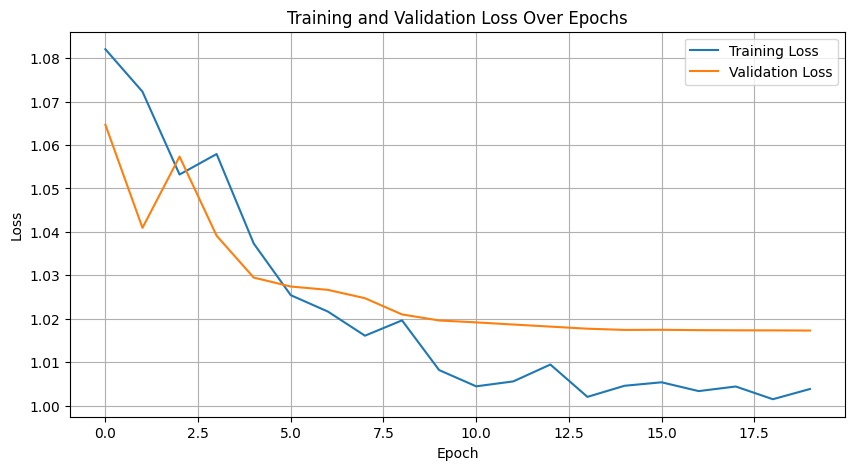

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [1]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'train_accuracies' is not defined

<Figure size 1000x500 with 0 Axes>

In [11]:
import os
import requests
import zipfile
from tqdm import tqdm
import numpy as np
import mne
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torch.optim import lr_scheduler

# -----------------------------
# CONFIG
# -----------------------------
RAW_ARTICLE_ID = 28831730
PREPROC_ARTICLE_ID = 28837016

DATA_DIR = "data"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# STEP 1: GET TRUE DOWNLOAD LINKS
# -----------------------------
def get_figshare_links(article_id):
    url = f"https://api.figshare.com/v2/articles/{article_id}/files"
    files = requests.get(url).json()

    links = []
    for f in files:
        print(f"{f['name']} -> {f['download_url']}")
        links.append(f["download_url"])

    return links

print("\nFetching links...")
rw_links = get_figshare_links(RAW_ARTICLE_ID)
preproc_links = get_figshare_links(PREPROC_ARTICLE_ID)

# -----------------------------
# STEP 2: DOWNLOAD WITH PROGRESS
# -----------------------------
def download_file(url, save_path):
    if os.path.exists(save_path):
        print(f"Already exists: {save_path}")
        return

    response = requests.get(url, stream=True)
    total_size = int(response.headers.get('content-length', 0))

    with open(save_path, 'wb') as file, tqdm(
        desc=save_path,
        total=total_size,
        unit='B',
        unit_scale=True
    ) as bar:
        for chunk in response.iter_content(chunk_size=8192):
            file.write(chunk)
            bar.update(len(chunk))

def download_and_extract_all(links, folder):
    os.makedirs(folder, exist_ok=True)

    for url in links:
        filename = url.split("/")[-1]
        zip_path = os.path.join(folder, filename)

        print(f"\nDownloading {filename}...")
        download_file(url, zip_path)

        print(f"Extracting {filename}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(folder)

# -----------------------------
# STEP 3: DOWNLOAD DATA
# -----------------------------
# 👉 Start ONLY with preprocessed for now
download_and_extract_all(preproc_links[:1], os.path.join(DATA_DIR, "preprocessed"))

# -----------------------------
# STEP 4: LOAD EEGLAB DATA
# -----------------------------
def load_eeglab_file(file_path):
    # Use read_epochs_eeglab for data with multiple trials (epochs)
    epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)

    # The data is already epoched (n_epochs, n_channels, n_times)
    X = epochs.get_data()

    # The labels are the event IDs for each epoch (third column of epochs.events)
    # These are typically 1-indexed from MNE, so we convert to 0-indexed for PyTorch CrossEntropyLoss
    y = epochs.events[:, 2] - 1 # Subtract 1 to make labels 0-indexed

    # Display event mapping after 0-indexing adjustment for clarity
    adjusted_event_id = {k: v - 1 for k, v in epochs.event_id.items()}
    print("Event mapping (after 0-indexing adjustment):", adjusted_event_id)

    # The original windowing logic is replaced as the data is already in epochs

    return X, y

def load_dataset(folder):
    X_all, y_all = [], []

    for root, _, files in os.walk(folder):
        for file in files:
            if file.endswith(".set"):
                path = os.path.join(root, file)
                print(f"Loading {path}")

                X, y = load_eeglab_file(path)

                if len(X) > 0:
                    X_all.append(X)
                    y_all.append(y)

    X_all = np.concatenate(X_all, axis=0)
    y_all = np.concatenate(y_all, axis=0)

    return X_all, y_all

# -----------------------------
# STEP 5: DATASET CLASS
# -----------------------------
class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# -----------------------------
# STEP 6: MODEL
# -----------------------------
class CNN_LSTM(nn.Module):
    def __init__(self, n_channels, n_classes):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(n_channels, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.25),

            nn.Conv1d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.25),

            nn.Conv1d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.25),

            nn.Conv1d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.25)
        )

        self.lstm = nn.LSTM(256, 128, batch_first=True)
        self.dropout_fc = nn.Dropout(0.5)
        self.fc = nn.Linear(128, n_classes)

    def forward(self, x):
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        _, (h, _) = self.lstm(x)
        x = self.dropout_fc(h[-1])
        return self.fc(x)

# -----------------------------
# STEP 7: TRAINING
# -----------------------------
def train_model(X, y):
    # Normalize
    X = (X - X.mean()) / (X.std() + 1e-6)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y
    )

    train_loader = DataLoader(EEGDataset(X_train, y_train), batch_size=32, shuffle=True)
    test_loader = DataLoader(EEGDataset(X_test, y_test), batch_size=32)

    model = CNN_LSTM(X.shape[1], len(np.unique(y))).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1) # Add scheduler
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    val_losses = []
    train_accuracies = [] # Added to store training accuracies
    val_accuracies = []   # Added to store validation accuracies

    for epoch in range(20):
        model.train()
        total_loss = 0
        train_correct = 0 # Added for training accuracy
        train_total = 0   # Added for training accuracy

        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            train_preds = out.argmax(1) # Added for training accuracy
            train_correct += (train_preds == yb).sum().item() # Added for training accuracy
            train_total += len(yb) # Added for training accuracy

        train_losses.append(total_loss / len(train_loader))
        train_accuracies.append(train_correct / train_total) # Store training accuracy

        # Eval
        model.eval()
        correct, total = 0, 0
        val_loss = 0

        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(DEVICE)
                preds = model(xb).argmax(1).cpu()
                loss = criterion(model(xb), yb.to(DEVICE))
                val_loss += loss.item()

                correct += (preds == yb).sum().item()
                total += len(yb)
        val_losses.append(val_loss / len(test_loader))
        val_accuracies.append(correct / total) # Store validation accuracy

        print(f"Epoch {epoch+1} | Loss: {total_loss:.3f} | Acc: {correct/total:.4f}")
        scheduler.step()

    return model, X_test, y_test, train_losses, val_losses, train_accuracies, val_accuracies

# -----------------------------
# RUN PIPELINE
# -----------------------------
data_folder = os.path.join(DATA_DIR, "preprocessed")

X, y = load_dataset(data_folder)
print("Final dataset shape:", X.shape, y.shape)

model, X_test_final, y_test_final, train_losses, val_losses, train_accuracies, val_accuracies = train_model(X, y)


Fetching links...
Raw_EEG_Data_01_05.zip -> https://ndownloader.figshare.com/files/57432889
Raw_EEG_Data_06_10.zip -> https://ndownloader.figshare.com/files/57433693
Raw_EEG_Data_11_15.zip -> https://ndownloader.figshare.com/files/57435691
Raw_EEG_Data_15_20.zip -> https://ndownloader.figshare.com/files/57435694
Raw_EEG_Data_21_25.zip -> https://ndownloader.figshare.com/files/57560707
Raw_EEG_Data_26_30.zip -> https://ndownloader.figshare.com/files/57560710
README.m -> https://ndownloader.figshare.com/files/57561298
preICA_01_10.zip -> https://ndownloader.figshare.com/files/53889107
preICA_11_20.zip -> https://ndownloader.figshare.com/files/53889155
preICA_21_30.zip -> https://ndownloader.figshare.com/files/53889209
preprocessing_MI.m -> https://ndownloader.figshare.com/files/53889245
README.m -> https://ndownloader.figshare.com/files/57403708

Already exists: data/preprocessed/53889107
Extracting 53889107...
Loading data/preprocessed/S202_preICA.set
Event mapping (after 0-indexing ad

/tmp/ipykernel_3904/2424171358.py:86: RuntimeWarning: Data file name in EEG.data (S209_preICA1.fdt) is incorrect, the file name must have changed on disk, using the correct file name (S209_preICA.fdt).
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Event mapping (after 0-indexing adjustment): {'3': 0, '1': 1, '2': 2}
Loading data/preprocessed/S210_preICA.set
Event mapping (after 0-indexing adjustment): {'3': 0, '1': 1, '2': 2}
Loading data/preprocessed/S205_preICA.set
Event mapping (after 0-indexing adjustment): {'3': 0, '1': 1, '2': 2}
Loading data/preprocessed/S201_preICA.set


/tmp/ipykernel_3904/2424171358.py:86: RuntimeWarning: Data file name in EEG.data (S201_preICA1.fdt.fdt) is incorrect, the file name must have changed on disk, using the correct file name (S201_preICA.fdt).
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Event mapping (after 0-indexing adjustment): {'3': 0, '1': 1, '2': 2}
Loading data/preprocessed/S204_preICA.set
Event mapping (after 0-indexing adjustment): {'3': 0, '1': 1, '2': 2}
Loading data/preprocessed/S203_preICA.set
Event mapping (after 0-indexing adjustment): {'3': 0, '1': 1, '2': 2}
Loading data/preprocessed/S208_preICA.set
Event mapping (after 0-indexing adjustment): {'3': 0, '1': 1, '2': 2}
Final dataset shape: (5169, 59, 2048) (5169,)
Epoch 1 | Loss: 139.834 | Acc: 0.4236
Epoch 2 | Loss: 137.508 | Acc: 0.4178
Epoch 3 | Loss: 136.638 | Acc: 0.4371
Epoch 4 | Loss: 133.753 | Acc: 0.4110
Epoch 5 | Loss: 133.301 | Acc: 0.4255
Epoch 6 | Loss: 131.594 | Acc: 0.4458
Epoch 7 | Loss: 129.864 | Acc: 0.4449
Epoch 8 | Loss: 129.131 | Acc: 0.4429
Epoch 9 | Loss: 128.626 | Acc: 0.4381
Epoch 10 | Loss: 127.434 | Acc: 0.4371
Epoch 11 | Loss: 127.484 | Acc: 0.4381
Epoch 12 | Loss: 126.861 | Acc: 0.4410
Epoch 13 | Loss: 126.812 | Acc: 0.4371
Epoch 14 | Loss: 127.167 | Acc: 0.4333
Epoch 15 | 